In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [32]:
gamma = 0.8
k = 10 
h = 2
t0 = 0 
tf = 10 
t = np.arange(t0,tf+1,h)
n = int((tf - t0)/h)

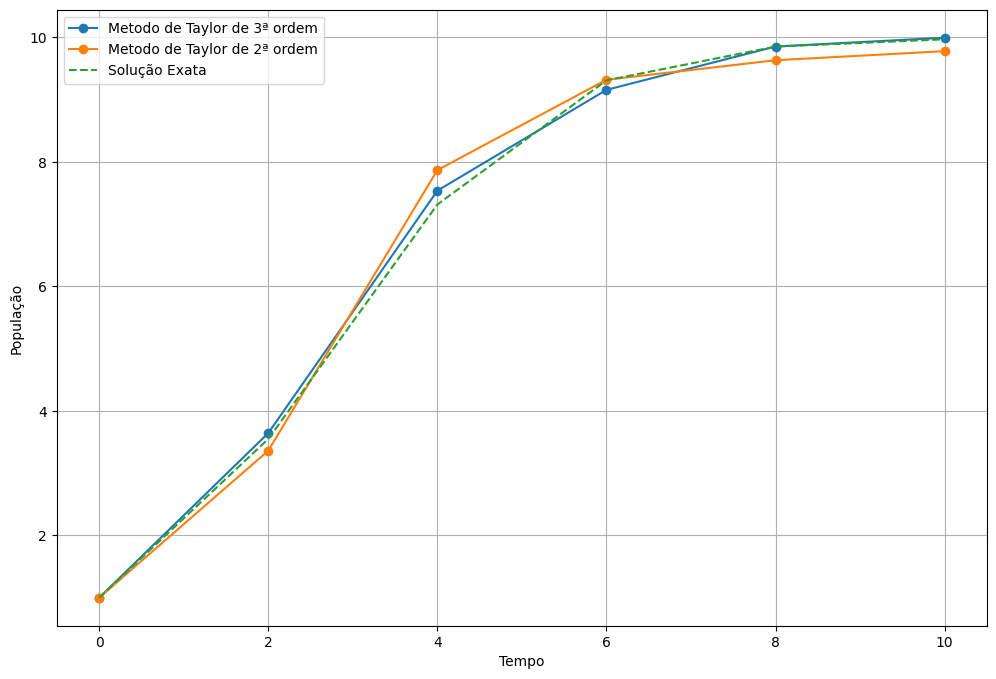

3.5497892312895107


In [40]:
def f(x): 
    return gamma*x *(1 - (x/k))

def dfdx(x):
    return (gamma - ((2*gamma*x)/k)) * f(x)

def dfdx2(x):
    return (gamma**3)*x*(1 - (x/k)) * (1 - (6*x/k)*(1 - (x/k)))

def solucao_exata(t,x0):
    return k/(1 + ((k-x0)/x0)*np.exp(-gamma*t))

p = np.zeros(n+1)
p2 = np.zeros(n+1)
p2[0] = 1.0
p[0] = 1.0


def metodoTaylor(p, t, h,ordem):
    if ordem == 1:
        for i in range(n): 
            p[i+1] = (p[i] + h*f(p[i])) + (((h**2)/2) * dfdx(p[i]))
    
    else:
        for i in range(n):
            p[i+1] = p[i] + h*f(p[i]) + ((h**2)/2) * dfdx(p[i]) + ((h**3)/6) * dfdx2(p[i])
    
    
    return p

p = metodoTaylor(p, t, h,0)
p2 = metodoTaylor(p2, t, h,1)

plt.figure(figsize=(12,8))
plt.plot(t,p,marker = 'o',label = 'Metodo de Taylor de 3ª ordem')
plt.plot(t,p2,marker = 'o',label = 'Metodo de Taylor de 2ª ordem')
plt.plot(t, solucao_exata(t,p[0]), label = 'Solução Exata', linestyle = '--')
plt.legend()
plt.xlabel('Tempo')
plt.ylabel('População')
plt.grid(True)
plt.show()


print(solucao_exata(2,p[0]))